# Lost Generation? Youth Unemployment in Spain Before and After COVID-19

## Load Data

In [ ]:
# setup Libraries
import pandas as pd
import geopandas as gpd
import folium
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
# load geo-map data
geo_spain = gpd.read_file('https://raw.githubusercontent.com/codeforgermany/click_that_hood/main/public/data/spain-communities.geojson')

# load data
df = pd.read_csv('65334.csv', sep='\t', encoding='utf-8-sig',decimal=',')

# explore data
print(df.shape)
print(df.head())

(40740, 5)
          Sexo Comunidades y Ciudades Autónomas   Edad Periodo  Total
0  Ambos sexos                   Total Nacional  Total  2026T1  10,83
1  Ambos sexos                   Total Nacional  Total  2025T4   9,93
2  Ambos sexos                   Total Nacional  Total  2025T3  10,45
3  Ambos sexos                   Total Nacional  Total  2025T2  10,29
4  Ambos sexos                   Total Nacional  Total  2025T1  11,36


In [ ]:
# describe data
display(df.describe())

# data infos
df.info()

,Sexo,Comunidades y Ciudades Autónomas,Edad,Periodo,Total
count,40740,40740,40740,40740,40740
unique,3,20,7,97,7092
top,Ambos sexos,Total Nacional,Total,2026T1,"100,00"
freq,13580,2037,5820,420,252


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40740 entries, 0 to 40739
Data columns (total 5 columns):
 #   Column                            Non-Null Count  Dtype 
---  ------                            --------------  ----- 
 0   Sexo                              40740 non-null  object
 1   Comunidades y Ciudades Autónomas  40740 non-null  object
 2   Edad                              40740 non-null  object
 3   Periodo                           40740 non-null  object
 4   Total                             40740 non-null  object
dtypes: object(5)
memory usage: 1.6+ MB


## Data Processing

In [ ]:
## Convert the data  type of 'Total'
df['Total']=df['Total'].str.replace(',','.')
df['Total']=pd.to_numeric(df['Total'],errors='coerce')

# missing values
display('Missing values',df.isna().sum())

# checking the records where Total is null
df[df['Total'].isna()]


'Missing values'

,0
Sexo,0
Comunidades y Ciudades Autónomas,0
Edad,0
Periodo,0
Total,162


,Sexo,Comunidades y Ciudades Autónomas,Edad,Periodo,Total
12547,Ambos sexos,18 Ceuta,De 16 a 19 años,2017T3,NaN
12554,Ambos sexos,18 Ceuta,De 16 a 19 años,2015T4,NaN
13192,Ambos sexos,19 Melilla,De 16 a 19 años,2026T1,NaN
13194,Ambos sexos,19 Melilla,De 16 a 19 años,2025T3,NaN
13205,Ambos sexos,19 Melilla,De 16 a 19 años,2022T4,NaN
...,...,...,...,...,...
40721,Mujeres,19 Melilla,De 55 y más años,2006T3,NaN
40722,Mujeres,19 Melilla,De 55 y más años,2006T2,NaN
40724,Mujeres,19 Melilla,De 55 y más años,2005T4,NaN
40725,Mujeres,19 Melilla,De 55 y más años,2005T3,NaN


In [ ]:
# Ceuta/Melilla null values after 2019T1
df[
    (df['Comunidades y Ciudades Autónomas'].str.contains('Ceuta|Melilla'))&
    (df['Periodo']>='2019T1')].isna().sum()


,0
Sexo,0
Comunidades y Ciudades Autónomas,0
Edad,0
Periodo,0
Total,28


In [ ]:
# Delete Ceuta/Melilla records, There is no sufficient data for the analysis.
df = df[~df['Comunidades y Ciudades Autónomas'].str.contains('Ceuta|Melilla')]
print(df.shape)

(36666, 5)


In [ ]:
# Separat region name
region_map = {
    '01 Andalucía': 'Andalucia',
    '02 Aragón': 'Aragon',
    '03 Asturias, Principado de': 'Asturias',
    '04 Balears, Illes': 'Baleares',
    '05 Canarias': 'Canarias',
    '06 Cantabria': 'Cantabria',
    '07 Castilla y León': 'Castilla-Leon',
    '08 Castilla - La Mancha': 'Castilla-La Mancha',
    '09 Cataluña': 'Cataluña',
    '10 Comunitat Valenciana': 'Valencia',
    '11 Extremadura': 'Extremadura',
    '12 Galicia': 'Galicia',
    '13 Madrid, Comunidad de': 'Madrid',
    '14 Murcia, Región de': 'Murcia',
    '15 Navarra, Comunidad Foral de': 'Navarra',
    '16 País Vasco': 'Pais Vasco',
    '17 Rioja, La': 'La Rioja',
    'Total Nacional': 'Total Nacional'
}

df['region'] = df['Comunidades y Ciudades Autónomas'].map(region_map)

__________________
## ***Analysis***

***1-When was the peak? When did the recovery begin?***

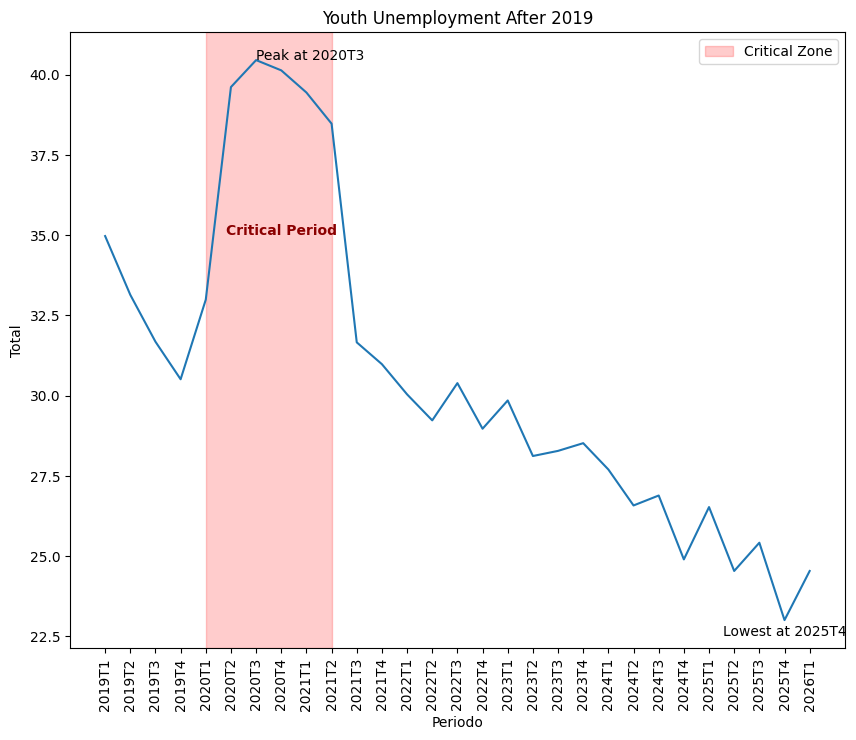

In [ ]:
# Keep only young ppl under 25
df_analysis1 = df[
    (df['Comunidades y Ciudades Autónomas'] == 'Total Nacional') &
    (df['Edad'] == 'Menores de 25 años') &
    (df['Sexo'] == 'Ambos sexos') &
    (df['Periodo'].str[:4].astype(int) >= 2019)
][['Periodo', 'Total']].sort_values(by='Periodo')

# plt
plt.figure(figsize=(10,8))
sns.lineplot(data=df_analysis1,x='Periodo',y='Total')
#labels
plt.title('Youth Unemployment After 2019')
plt.xticks(rotation=90)
# Annotation
idmax=df_analysis1['Total'].idxmax()
idmin=df_analysis1['Total'].idxmin()
peak_max=df_analysis1.loc[idmax][0:]
peak_min=df_analysis1.loc[idmin][0:]
plt.text(x=peak_max['Periodo'],y=peak_max['Total'],s=f'Peak at {peak_max['Periodo']}')
plt.text(x=peak_min['Periodo'],y=peak_min['Total']-0.5,s=f'Lowest at {peak_min['Periodo']}',ha='center')

# critical zone
start_zone = "2020T1"
end_zone = "2021T2"

plt.axvspan(
    start_zone,
    end_zone,
    color="red",
    alpha=0.2,
    label="Critical Zone",
)

plt.text(
    "2020T4",
    35,
    "Critical Period",
    color="darkred",
    fontweight="bold",
    ha="center",
)

plt.legend()
plt.show()

***Insights:***

The line Displays the overall youth unemployment rate (male/female) under the age of 25 across the country from Q1 2019 to Q1 2026.

The unemployment rate peaked in Q3 2020 at 40.5%, following a significant increase from approximately 30.3% in Q4 2019.

After Q2 2021, the unemployment rate began to decline sharply, reaching its lowest point in Q4 2025 at approximately 23%.

***Conclusion:*** The unemployment rate rose sharply during the critical period between Q1 2020 and Q2 2021, then began to recover and return to normal levels after this period, indicating that the COVID-19 pandemic had a significant impact on the labor market.

And by 2024, youth unemployment dropped below 2019 levels (pre-COVID), suggesting a strong recovery in the Spanish labor market after the pandemic.


____
***2-Were young people more affected than adults and the elderly?***

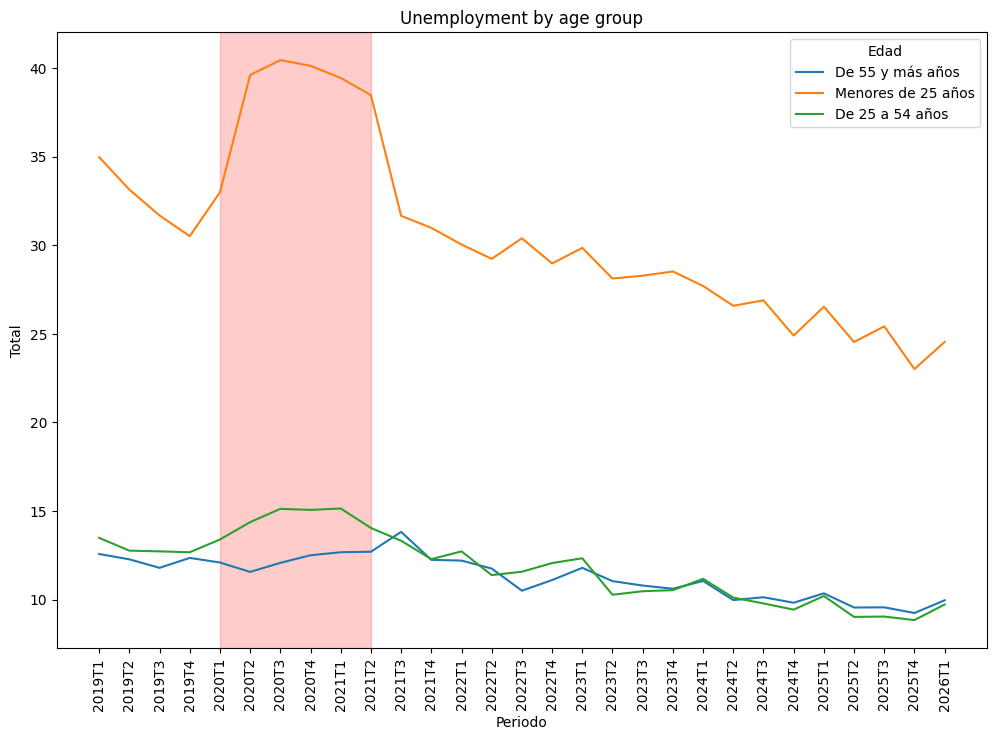

In [ ]:
# Age comparison
df_analysis2=df[
    # Young + Adults+ Elderly
    (df['Edad'].isin([
       'Menores de 25 años',
        'De 25 a 54 años',
       'De 55 y más años'
    ]))&

    # Male And female
    (df['Sexo']=='Ambos sexos')&
    (df['Comunidades y Ciudades Autónomas']=='Total Nacional')&
    ((df['Periodo'].str[:4].astype(int) >= 2019))
][['Edad','Periodo','Total']].sort_values(by='Periodo')

# plot
plt.figure(figsize=(12,8))
sns.lineplot(
    data=df_analysis2,
    x='Periodo',
    y='Total',
    hue='Edad')
# Labels
plt.xticks(rotation=90)
plt.title('Unemployment by age group')

# critical period
start_zone = "2020T1"
end_zone = "2021T2"

plt.axvspan(
    start_zone,
    end_zone,
    color="red",
    alpha=0.2,
    label="Critical Zone",
)


***Insights:*** The multi-line graph compares unemployment rates across different age groups from the first quarter of 2019 to the first quarter of 2026.

Young people under 25 years of age had the highest overall unemployment rate during this period and were the hardest hit during the COVID-19 pandemic, with unemployment rates ranging from 33% to 41% during this critical period. The unemployment rate among adults ranged from 12% to 16%, and among older adults from 11% to 13%.

**Conclusion:*** Young people were the hardest hit during the pandemic and continue to have the highest unemployment rates  and in the most of cases they represent the double of the unemployment rate for ulder people between 25-54, while The elderly group were the least affected, This persistent gap suggests that young workers in Spain face structural barriers to employment, regardless of economic conditions.



______________
***3-Were young women more affected?***

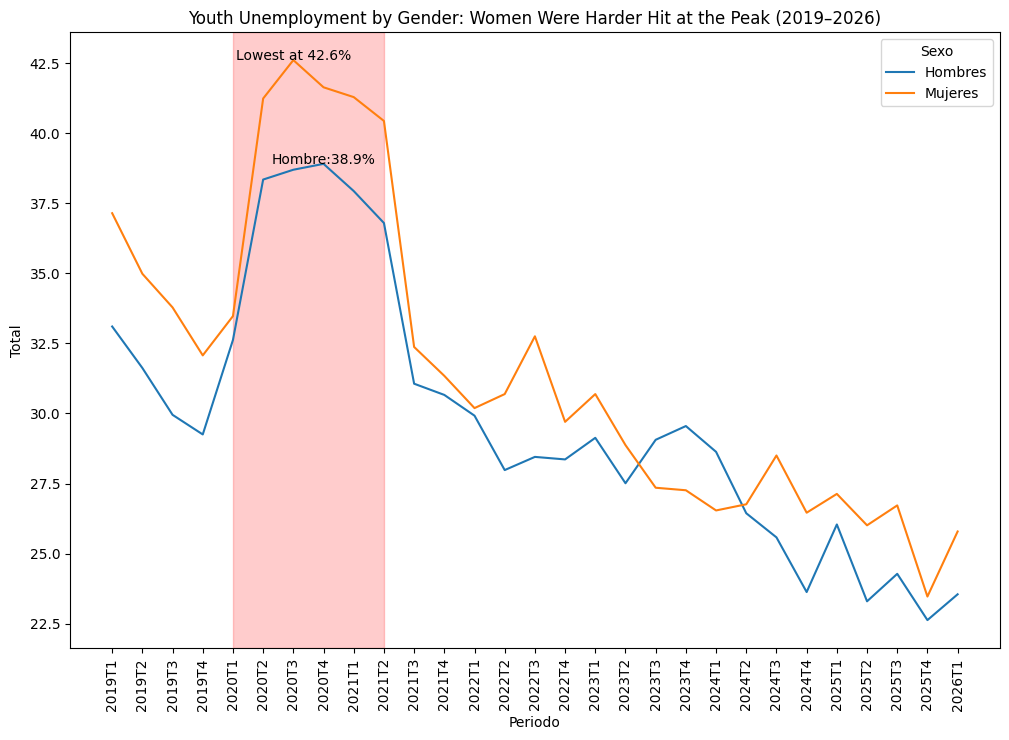

In [27]:
# Sex comparison
df_analysis3=df[
    # Young
    (df['Edad'].isin([
       'Menores de 25 años',
    ]))&

    # Male And female separated
    (df['Sexo'].isin([
        'Hombres',
        'Mujeres'
    ]))&
    (df['Comunidades y Ciudades Autónomas']=='Total Nacional')&
    ((df['Periodo'].str[:4].astype(int) >= 2019))
][['Sexo','Periodo','Total']].sort_values(by='Periodo')

# plot
plt.figure(figsize=(12,8))
sns.lineplot(
    data=df_analysis3,
    x='Periodo',
    y='Total',
    hue='Sexo')
# Labels
plt.xticks(rotation=90)
plt.title('Youth Unemployment by Gender: Women Were Harder Hit at the Peak (2019–2026)')
# text

idmax_H=df_analysis3[df_analysis3['Sexo']=='Hombres']['Total'].idxmax()
idmax_M=df_analysis3[df_analysis3['Sexo']=='Mujeres']['Total'].idxmax()

peak_H=df_analysis3.loc[idmax_H][0:]
peak_M=df_analysis3.loc[idmax_M][0:]
plt.text(x=peak_H['Periodo'],y=peak_H['Total'],s=f'Hombre:{peak_H['Total']}%',ha='center')
plt.text(x=peak_M['Periodo'],y=peak_M['Total'],s=f'Lowest at {peak_M['Total']}%',ha='center')

# critical period
start_zone = "2020T1"
end_zone = "2021T2"

plt.axvspan(
    start_zone,
    end_zone,
    color="red",
    alpha=0.2,
    label="Critical Zone",
)




***Conclusion:*** Young women were hit harder than men at the peak: 42.6% vs 38.9%. The difference looks small, but it means hundreds of thousands of extra women without a job. By 2024, both lines got much closer, showing that the gap between men and women is slowly closing. Suggesting gradual gender convergence in youth unemployment.


___________________________
***4-Which region was most affected at the peak of COVID?***

In [25]:
df_analysis = df[
    (df["Edad"] == "Menores de 25 años") &
    (df["Sexo"] == "Ambos sexos") &
    (df["Comunidades y Ciudades Autónomas"] != "Total Nacional")
].copy()

# Pandemic period
pandemic = df_analysis[
    df_analysis["Periodo"].isin(
        ["2020T1","2020T2","2020T3","2020T4",
         "2021T1","2021T2"]
    )
]

# Peak unemployment for each region
peak = (
    pandemic.groupby("region")["Total"]
    .max()
    .rename("peak_rate")
    .reset_index()
)

sp_geo_region= geo_spain.rename(columns={'name': 'region'})
sp_geo_region = sp_geo_region.merge(peak, on='region', how='left')
# We only keep the ID, the Geometry, and the Count
map_data = sp_geo_region[['region', 'peak_rate', 'geometry']]

# Choropleth Function
def Choropleth_f(data,values,legend=None):
  m = folium.Map(location=[40.4, -3.7], zoom_start=6)
  folium.Choropleth(
      geo_data=data,
      data=data,
      columns=['region', values],
      fill_color='YlOrBr',
      key_on='feature.properties.region',
      fill_opacity=0.7,
      line_opacity=0.2,
      legend_name=legend
  ).add_to(m)

  folium.GeoJson(
      data,
      tooltip=folium.GeoJsonTooltip(
          fields=['region', values],
          aliases=['region:', 'Unemployment:'],
          localize=True
      )
  ).add_to(m)



  folium.LayerControl().add_to(m)

  return m
# display the map
m1=Choropleth_f(
    data=map_data,
    values='peak_rate',
    legend='Rate'
)

m1


The choropleth map displays the unemployment rate by different Spanish regions at the peak of the pandemic of each region. The Canary Islands recorded the highest rate at 62%.72%, followed by Cantabria at 57.1%, Extremadura at 56.1%, Andalucia at 52% . On the other hand, regions like Cataluña, Navarra, La Rioja, Aragón and  Madrid galicia and castilla-leon recorded the lowest levels, around 29%–33%.

***Conclusion:*** The Canary Islands, Andalucía and Extremadura recorded the highest youth unemployment rates during the pandemic, sometimes exceeding 50%. Meanwhile, the 'Ebro Axis' regions (northern-eastern Spain) and the Industrial regions recorded the lowest rates, suggesting that geographic location, closeness to European markets, and economic structure all may contribute to labor market resilience, especially for young workers.

The high rates in Canarias are largely related to its heavy dependence on tourism, which collapsed during the pandemic.

_______________________
***5-Which region recovered the fastest by 2024?***

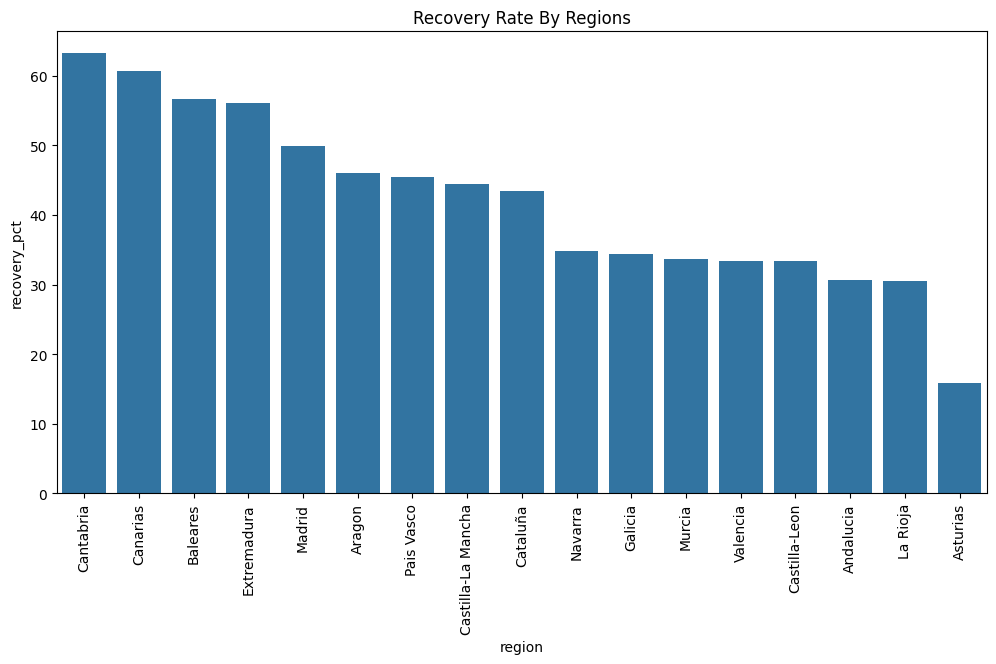

In [19]:
# Base filter
df_analysis = df[
    (df["Edad"] == "Menores de 25 años") &
    (df["Sexo"] == "Ambos sexos") &
    (df["Comunidades y Ciudades Autónomas"] != "Total Nacional")
].copy()

# Pandemic period
pandemic = df_analysis[
    df_analysis["Periodo"].isin(
        ["2020T1","2020T2","2020T3","2020T4",
         "2021T1","2021T2"]
    )
]

# Peak unemployment for each region
peak = (
    pandemic.groupby("region")["Total"]
    .max()
    .rename("peak_rate")
)

# 2024T4 values
latest = (
    df_analysis[df_analysis["Periodo"] == "2024T4"]
    .set_index("region")["Total"]
    .rename("rate_2024T4")
)

# Merge
recovery_df = pd.concat([peak, latest], axis=1)

# Recovery %
recovery_df["recovery_pct"] = (
    (recovery_df["peak_rate"] - recovery_df["rate_2024T4"])
    / recovery_df["peak_rate"]
) * 100

recovery_df=recovery_df.sort_values("recovery_pct", ascending=False)

# plot
plt.figure(figsize=(12,6))
sns.barplot(
    data=recovery_df,
    x=recovery_df.index,
    y=recovery_df['recovery_pct']
)
plt.title('Recovery Rate By Regions')
plt.xticks(rotation=90,size=10)
plt.show()

***Insights:*** The graph compares unemployment recovery rates across Spanish regions between each region's pandemic peak (2020Q1–2021Q2) and Q4 2024. Most regions showed a strong recovery in youth unemployment by 2024. Canarias recorded the highest recovery rate, reducing unemployment by around 60% from its peak despite being one of the regions hardest hit during the pandemic. Asturias had the lowest recovery rate, suggesting that youth unemployment remains a more persistent issue there than in other regions.

Overall, the results indicate that Spain's youth labor market has recovered substantially since the pandemic, although recovery has not been uniform across all regions.


_______________
***6-Has Austria recovered recently?***

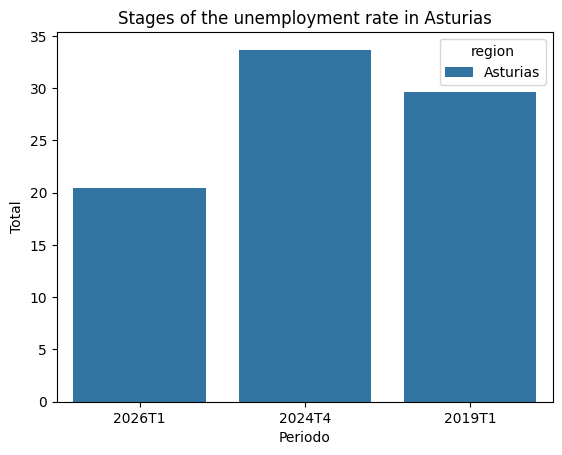

In [13]:
# filtering
df_analysis6 = df[
    (df["Edad"] == "Menores de 25 años")
    & (df["Sexo"] == "Ambos sexos")
    & (df["Periodo"].isin(["2019T1", "2024T4","2026T1"]))
    & (df["region"] == "Asturias")
][['region','Periodo','Total']]

# plot
plt.figure()
sns.barplot(
    data=df_analysis6,
    x='Periodo',
    y='Total',
    hue='region'
)
plt.title('Stages of the unemployment rate in Asturias')
plt.show()

***Insights:***
After the decline that followed the pandemic, the labor market in Asturias has recently seen a remarkable recovery, As the unemployment rate reaching 29.59% in the first quarter of 2019, 33.68% in the fourth quarter of 2024, and finally 20.41% in the first quarter of 2026.

_____________________________
## ***Conclusion:***
The Spanish labor market faced several challenges during the COVID-19 pandemic, including:

- High unemployment rates across the country, peaking at 40.5% in the third quarter of 2020.

- Young people were the hardest hit, with unemployment reaching a peak of 41%, and young women experiencing the highest rate at 42% during this period.

- Regions most reliant on tourism and exports (agriculture) were the most affected, such as the Canary Islands (62%) and Extremadura (56%).

- Asturias experienced the slowest recovery among all regions, remaining the
only region where youth unemployment in 2024 was still higher than pre-COVID
levels (2019), suggesting structural economic challenges beyond the pandemic.

- Although youth unemployment has improved compared to pandemic levels, it remains structurally double that of adults aged 25–54, highlighting the need for targeted policies to support young workers.

- Overall, Spain has seen a significant recovery since the pandemic.